# AIRL vs GAIL Comparison (imitation ライブラリ)

このノートブックは `imitation` ライブラリを使用して AIRL と GAIL を比較します。

- **AIRL**: Adversarial Inverse Reinforcement Learning (逆強化学習)
- **GAIL**: Generative Adversarial Imitation Learning (敵対的模倣学習)

両方とも Stable Baselines3 の PPO をベースにしています。

In [1]:
# パス設定
import sys
import os

# 現在のディレクトリをパスに追加
current_dir = os.path.dirname(os.path.abspath('__file__'))
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

In [2]:
# インポート
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

from pathlib import Path
import config
from td3_runner import train_expert, evaluate_expert
from IRL_lib.airl_runner import train_airl, evaluate_airl
from GAIL_lib.gail_runner import train_gail, evaluate_gail
from collect_expert_trajectories import collect_expert_trajectories

print("インポート完了")

インポート完了


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## 0. エキスパートの学習 (TD3)

模倣学習のためのエキスパート（教師データ生成用）を学習させます。

pybullet build time: Dec  5 2025 16:32:26


エキスパート(TD3)の学習を開始します...
argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886
startThreads creating 1 threads.
starting thread 0
started thread 0 
argc=5
argv[0] = --unused
argv[1] = --background_color_red=0.8745098114013672
argv[2] = --background_color_green=0.21176470816135406
argv[3] = --background_color_blue=0.1764705926179886
argv[4] = --start_demo_name=Physics Server
ExampleBrowserThreadFunc started
X11 functions dynamically loaded using dlopen/dlsym OK!
X11 functions dynamically loaded using dlopen/dlsym OK!
Creating context
Created GL 3.3 context
Direct GLX rendering context obtained
Making context current
GL_VENDOR=Mesa
GL_RENDERER=llvmpipe (LLVM 20.1.2, 256 bits)
GL_VERSION=4.5 (Core Profile) Mesa 25.0.7-0ubuntu0.24.04.2
GL_SHADING_LANGUAGE_VERSION=4.50
pthread_getconcurrency()=0
Version = 4.5 (Core Profile) Mesa 25.0.7-0ubuntu0.24.04.2
Vendor = Mesa
Renderer = llvmpipe (LLVM 2

Training..:  10%|█         | 51/500 [00:12<02:02,  3.66it/s]

Episode: 50 	 Steps: 50 	 Score: -50.0 	 Recent Avg Score: -49.2 	 Success: 1/50 (2.0%)


Training..:  20%|██        | 102/500 [00:21<00:51,  7.66it/s]

...

Training..:  81%|████████  | 403/500 [00:51<00:09, 10.03it/s]

Episode: 400 	 Steps: 3 	 Score: -2.0 	 Recent Avg Score: -1.9 	 Success: 50/50 (100.0%)


Training..:  91%|█████████ | 453/500 [00:56<00:04, 11.15it/s]

Episode: 450 	 Steps: 3 	 Score: -2.0 	 Recent Avg Score: -1.9 	 Success: 50/50 (100.0%)


Training..: 100%|██████████| 500/500 [01:00<00:00,  8.21it/s]


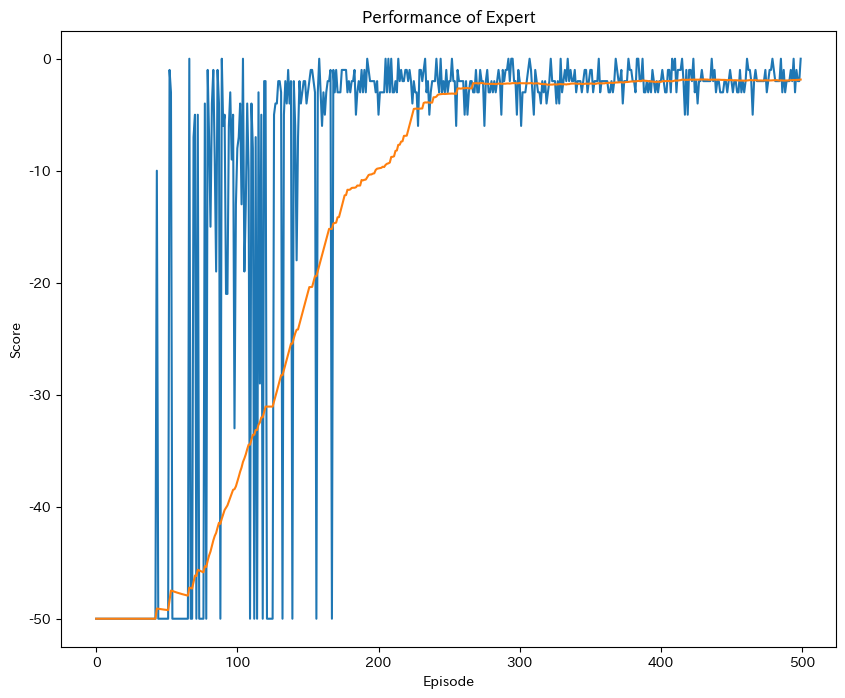

Expert model saved to /home/shimoiyusuke/manipulator-inverse-rl/Library/Models/Expert

--- TD3 Expert Stats (per 50 episodes) ---
Chunk  Range           Success    Fail       Rate      
------------------------------------------------------------
0      0-49            1.0        49.0         2.00%
1      50-99           27.0       23.0        54.00%
2      100-149         39.0       11.0        78.00%
3      150-199         48.0       2.0         96.00%
4      200-249         50.0       0.0        100.00%
5      250-299         50.0       0.0        100.00%
6      300-349         50.0       0.0        100.00%
7      350-399         50.0       0.0        100.00%
8      400-449         50.0       0.0        100.00%
9      450-499         50.0       0.0        100.00%



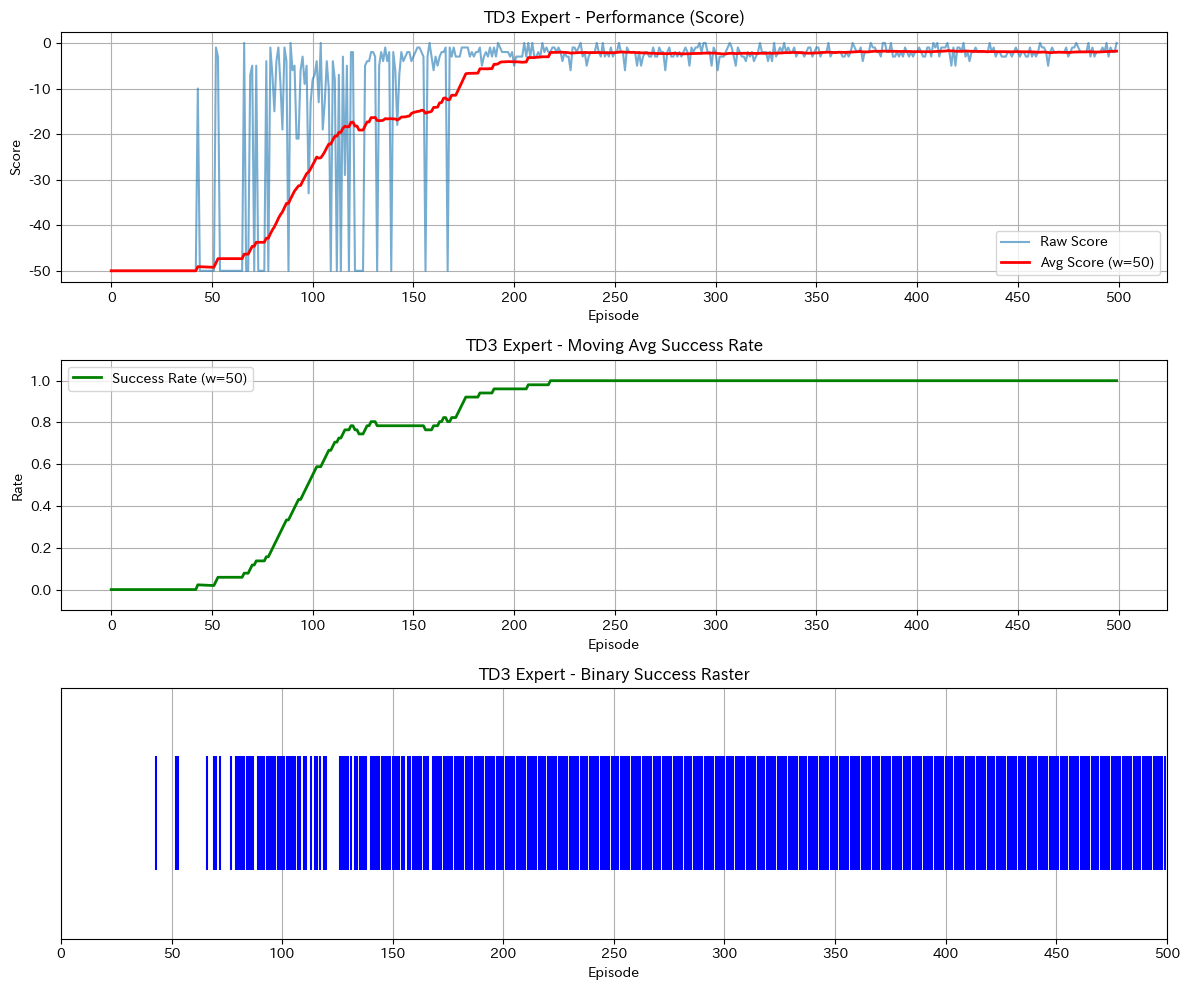

エキスパートの学習完了。評価を行います...
numActiveThreads = 0
stopping threads
Thread with taskId 0 exiting
Thread TERMINATED
destroy semaphore
semaphore destroyed
destroy main semaphore
main semaphore destroyed
finished
numActiveThreads = 0
btShutDownExampleBrowser stopping threads
Thread with taskId 0 exiting
Thread TERMINATED
destroy semaphore
semaphore destroyed
destroy main semaphore
main semaphore destroyed
argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886
startThreads creating 1 threads.
starting thread 0
started thread 0 
argc=5
argv[0] = --unused
argv[1] = --background_color_red=0.8745098114013672
argv[2] = --background_color_green=0.21176470816135406
argv[3] = --background_color_blue=0.1764705926179886
argv[4] = --start_demo_name=Physics Server
ExampleBrowserThreadFunc started
X11 functions dynamically loaded using dlopen/dlsym OK!
X11 functions dynamically loaded using dlopen/dlsym OK!
Crea

Evaluating:   0%|          | 2/500 [00:00<00:36, 13.79it/s]

ven = Mesa
ven = Mesa


Evaluating: 100%|██████████| 500/500 [00:14<00:00, 34.06it/s]


TD3 Expert Evaluation: Mean Return = -1.870, Std = 0.995, Success: 500/500 (100.0%)

--- TD3 Expert (Eval) Stats (per 50 episodes) ---
Chunk  Range           Success    Fail       Rate      
------------------------------------------------------------
0      0-49            50         0          100.00%
1      50-99           50         0          100.00%
2      100-149         50         0          100.00%
3      150-199         50         0          100.00%
4      200-249         50         0          100.00%
5      250-299         50         0          100.00%
6      300-349         50         0          100.00%
7      350-399         50         0          100.00%
8      400-449         50         0          100.00%
9      450-499         50         0          100.00%



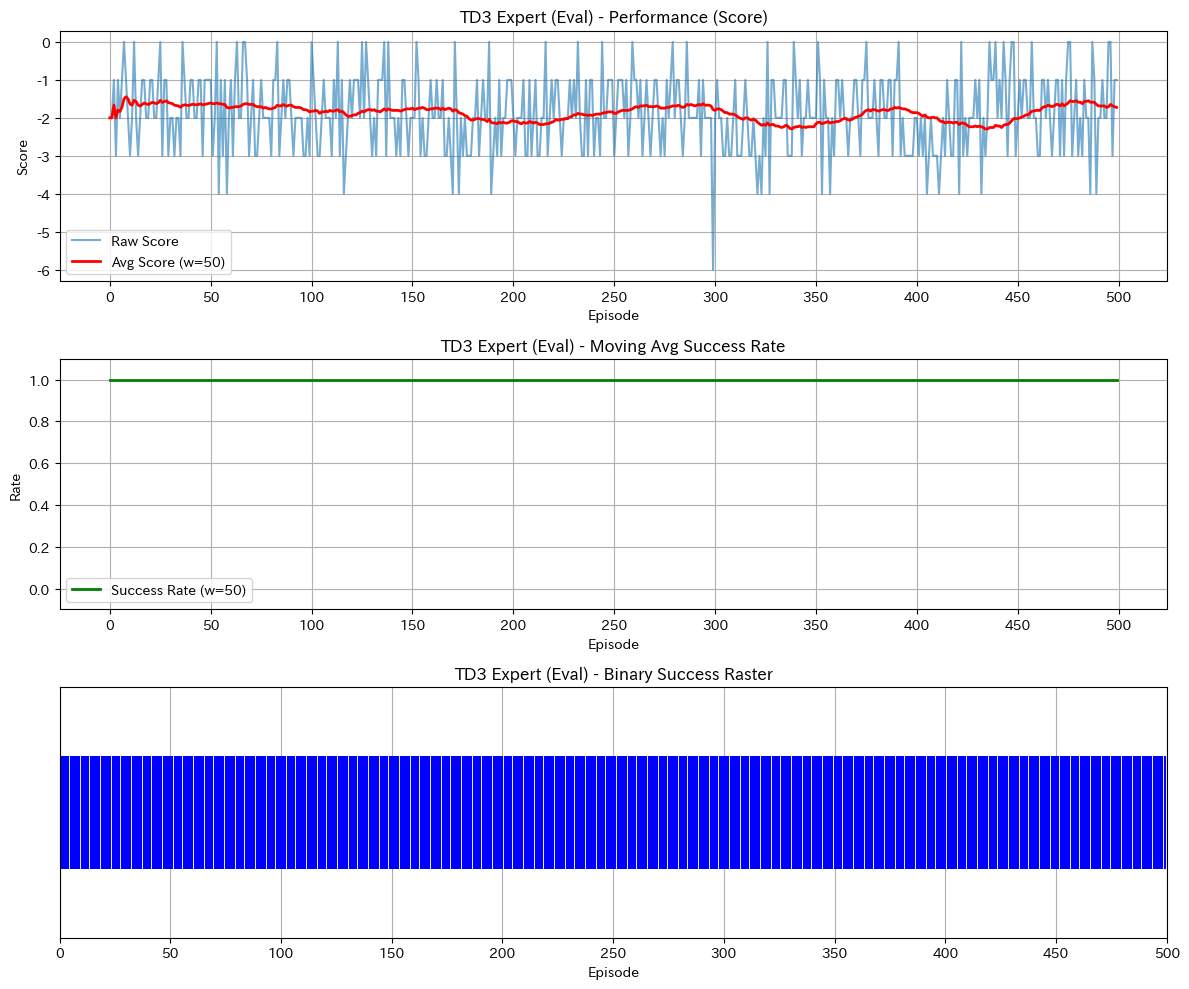

numActiveThreads = 0
stopping threads
エキスパートのモデルが保存されました。
Thread with taskId 0 exiting
Thread TERMINATED
destroy semaphore
semaphore destroyed
destroy main semaphore
main semaphore destroyed
finished
numActiveThreads = 0
btShutDownExampleBrowser stopping threads
Thread with taskId 0 exiting
Thread TERMINATED
destroy semaphore
semaphore destroyed
destroy main semaphore
main semaphore destroyed


In [3]:
# エキスパートの学習と評価
print("エキスパート(TD3)の学習を開始します...")
expert_agent, expert_train_results = train_expert()

print("エキスパートの学習完了。評価を行います...")
evaluate_expert(expert_agent)
print("エキスパートのモデルが保存されました。")

## 1. エキスパート軌跡の準備

AIRL と GAIL は両方ともエキスパートの軌跡データを必要とします。

In [4]:
# エキスパート軌跡の収集（存在しない場合）
if not config.EXPERT_TRAJECTORIES_PATH.exists():
    print("エキスパート軌跡を収集中...")
    collect_expert_trajectories(
        env_name="PandaReach-v3",
        episodes=200,
        steps_per_episode=300,
        save_path=str(config.EXPERT_TRAJECTORIES_PATH)
    )
else:
    print(f"エキスパート軌跡が見つかりました: {config.EXPERT_TRAJECTORIES_PATH}")

エキスパート軌跡が見つかりました: /home/shimoiyusuke/manipulator-inverse-rl/Library/expert_trajectories.pt


## 2. AIRL トレーニング (逆強化学習)

In [5]:
# AIRL トレーニング
print("AIRL トレーニング開始...")
airl_results = train_airl(n_episodes=config.N_EPISODES_APPRENTICE)
print(f"AIRL 完了: 平均報酬 = {airl_results['mean_reward']:.2f}")

AIRL トレーニング開始...
argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886
argv[0]=--background_color_red=0.8745098114013672
argv[1]=--background_color_green=0.21176470816135406
argv[2]=--background_color_blue=0.1764705926179886
Loading expert trajectories...
Loaded 200 expert trajectories
Using cuda device
Running with `allow_variable_horizon` set to True. Some algorithms are biased towards shorter or longer episodes, which may significantly confound results. Additionally, even unbiased algorithms can exploit the information leak from the termination condition, producing spuriously high performance. See https://imitation.readthedocs.io/en/latest/getting-started/variable-horizon.html for more information.
Evaluating before training...
Mean reward before training: -49.00
Training AIRL for 500 episodes...


round:   0%|          | 0/488 [00:00<?, ?it/s]

------------------------------------------
| raw/                        |          |
|    gen/rollout/ep_len_mean  | 41.5     |
|    gen/rollout/ep_rew_mean  | -41.3    |
|    gen/time/fps             | 273      |
|    gen/time/iterations      | 1        |
|    gen/time/time_elapsed    | 7        |
|    gen/time/total_timesteps | 2048     |
------------------------------------------
--------------------------------------------------
| raw/                                |          |
|    disc/disc_acc                    | 0.5      |
|    disc/disc_acc_expert             | 1        |
|    disc/disc_acc_gen                | 0        |
|    disc/disc_entropy                | 0.126    |
|    disc/disc_loss                   | 1.8      |
|    disc/disc_proportion_expert_pred | 1        |
|    disc/disc_proportion_expert_true | 0.5      |
|    disc/global_step                 | 1        |
|    disc/n_expert                    | 256      |
|    disc/n_generated                 | 256      |
-

round:   0%|          | 1/488 [00:08<1:08:55,  8.49s/it]

Episode: 50 	 Avg Score: -41.5 	 Success: 10/50 (20.0%)
----------------------------------------------------
| raw/                              |              |
|    gen/rollout/ep_len_mean        | 44.7         |
|    gen/rollout/ep_rew_mean        | -44.6        |
|    gen/time/fps                   | 298          |
|    gen/time/iterations            | 1            |
|    gen/time/time_elapsed          | 6            |
|    gen/time/total_timesteps       | 4096         |
|    gen/train/approx_kl            | 0.0028881505 |
|    gen/train/clip_fraction        | 0.133        |
|    gen/train/clip_range           | 0.1          |
|    gen/train/entropy_loss         | -4.26        |
|    gen/train/explained_variance   | -0.85867953  |
|    gen/train/learning_rate        | 0.0005       |
|    gen/train/loss                 | -0.00586     |
|    gen/train/n_updates            | 5            |
|    gen/train/policy_gradient_loss | -0.00781     |
|    gen/train/std                  | 1    

...

--------------------------------------------------
| raw/                                |          |
|    disc/disc_acc                    | 1        |
|    disc/disc_acc_expert             | 1        |
|    disc/disc_acc_gen                | 1        |
|    disc/disc_entropy                | 0.0109   |
|    disc/disc_loss                   | 0.00369  |
|    disc/disc_proportion_expert_pred | 0.5      |
|    disc/disc_proportion_expert_true | 0.5      |
|    disc/global_step                 | 488      |
|    disc/n_expert                    | 256      |
|    disc/n_generated                 | 256      |
--------------------------------------------------
--------------------------------------------------
| raw/                                |          |
|    disc/disc_acc                    | 1        |
|    disc/disc_acc_expert             | 1        |
|    disc/disc_acc_gen                | 1        |
|    disc/disc_entropy                | 0.00997  |
|    disc/disc_loss            

round: 100%|██████████| 488/488 [04:23<00:00,  1.85it/s]

Evaluating after training...


Mean reward after training: -47.11


TypeError: cannot pickle '_abc._abc_data' object

## 3. GAIL トレーニング (敵対的模倣学習)

In [ ]:
# GAIL トレーニング
print("GAIL トレーニング開始...")
gail_results = train_gail(n_episodes=config.N_EPISODES_APPRENTICE)
print(f"GAIL 完了: 平均報酬 = {gail_results['mean_reward']:.2f}")

## 4. 結果比較

In [ ]:
# 結果の比較プロット
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 報酬分布の比較
ax1 = axes[0]
ax1.boxplot(
    [list(airl_results['rewards_after']), list(gail_results['rewards_after'])],
    labels=['AIRL', 'GAIL']
)
ax1.set_ylabel('報酬')
ax1.set_title('トレーニング後の報酬分布')
ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='目標')
ax1.legend()

# 平均報酬の比較
ax2 = axes[1]
methods = ['AIRL', 'GAIL']
means = [airl_results['mean_reward'], gail_results['mean_reward']]
stds = [airl_results['std_reward'], gail_results['std_reward']]
colors = ['#1f77b4', '#ff7f0e']

bars = ax2.bar(methods, means, yerr=stds, capsize=5, color=colors, alpha=0.7)
ax2.set_ylabel('平均報酬')
ax2.set_title('AIRL vs GAIL: 平均報酬比較')
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)

# 値をバーの上に表示
for bar, mean, std in zip(bars, means, stds):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.5,
             f'{mean:.1f}±{std:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('Results/AIRL_vs_GAIL_Comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("比較グラフを保存しました: Results/AIRL_vs_GAIL_Comparison.png")

## 5. 結果サマリー

In [ ]:
# 結果サマリー
print("=" * 60)
print("結果サマリー")
print("=" * 60)
print(f"\n{'アルゴリズム':<15} {'平均報酬':<15} {'標準偏差':<15}")
print("-" * 45)
print(f"{'AIRL':<15} {airl_results['mean_reward']:<15.2f} {airl_results['std_reward']:<15.2f}")
print(f"{'GAIL':<15} {gail_results['mean_reward']:<15.2f} {gail_results['std_reward']:<15.2f}")
print("\n")

# どちらが良いか判定
if airl_results['mean_reward'] > gail_results['mean_reward']:
    winner = "AIRL"
    diff = airl_results['mean_reward'] - gail_results['mean_reward']
else:
    winner = "GAIL"
    diff = gail_results['mean_reward'] - airl_results['mean_reward']

print(f"結論: {winner} が {diff:.2f} ポイント優れています。")

## 6. モデル評価（オプション）

保存されたモデルを読み込んで評価します。

In [ ]:
# 保存されたモデルの評価
print("保存されたモデルを評価中...")

airl_eval = evaluate_airl(n_episodes=100)
gail_eval = evaluate_gail(n_episodes=100)

print(f"\nAIRL 評価: 平均報酬 = {airl_eval['mean_reward']:.2f} ± {airl_eval['std_reward']:.2f}")
print(f"GAIL 評価: 平均報酬 = {gail_eval['mean_reward']:.2f} ± {gail_eval['std_reward']:.2f}")